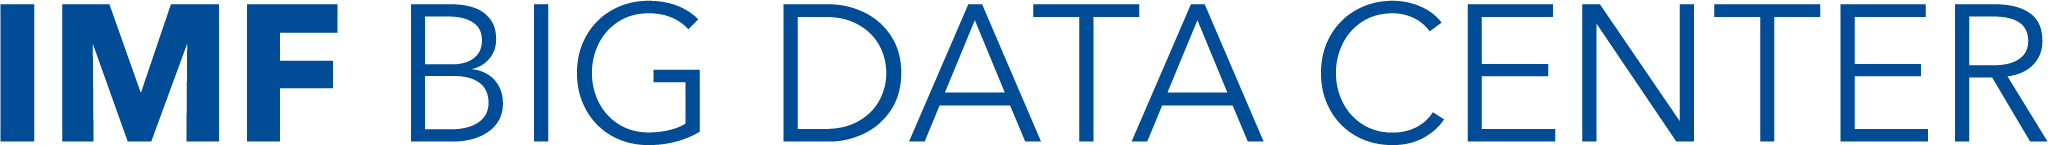

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/STI_2026/blob/main/notebooks/BDC_Working_With_AIS_PortWatch.ipynb)

---

<br>**Contributors:** [Alessandra Sozzi](asozzi@imf.org), [Dharana Rijal](drijal@imf.org) & [Mario Saraiva](msaraiva@imf.org)
<br> **Last update:** Oct-2025
<br> **Description:** This notebook showcases how to use the PortWatch API to download data. Then it gives different examples on how to use the data. In a fast-changing world of frequent disruptions, journalists, economists, policy-makers, and others need access to real-time data to make informed decisions during crises. This is where PortWatch comes in. Leveraging satellite-based vessel data and advanced big data analytics, PortWatch provides unparalleled insights into the domestic and international trade impacts of both current and future disasters.
<br> **References:**

## Working with Portwatch

### Objectives
- Using the Portwatch API to query data
- Create visualizations for different indicators (portcalls etc.)
- Compare Imports and Exports to official data
- Create a simple monitor

<details>
<summary><b>The data behind PortWatch</b> </summary>

PortWatch is based on Automatic Identification System (AIS) - is a system that allows ships to automatically transmit key information, such as position, speed, and identity, to other ships and shore stations. While it was originally developed as an anti-collision system, it has also evolved to act as a traffic control system for vessels, enhancing safety and operational efficiency.

Every ship is required to carry an AIS transmitter. These devices typically send positioning messages as frequently as every 2 to 10 seconds, depending on the ship's speed and the system configuration. While it's common to say that AIS acts like a "traffic control system for ships," it's important to note that the frequency of messages can vary based on the ship's movement.

</details>

### 1. Using the Portwatch API
The different dataset available throught the API are:
- Daily Port Activity Data and Trade Estimates (updated weekly)
- Daily Chokepoint Transit Calls and Trade Volume Estimates (updated weekly)
- Ports & Chokepoints
- Disruptions using the <a href="https://www.gdacs.org/">Global Disaster Alert and Coordination System (GDACS)</a>
- Spillover Simulator: Port-level impart; Country-level impact; supply chain impact
- Climate Scenarios

In [1]:
# Mounth the drive to access file in the Google Drive folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Set the main path for the workshop files

import os

ROOT = "/content/drive/MyDrive/STI_2026"
workshop_path = os.path.join(ROOT, "Day 3 - AIS and PortWatch")

# Check if working
print("Worshop path found: ", os.path.exists(workshop_path))

Worshop path found:  True


### Libraries

<H4> Installing Additional Library </H4>

In [4]:
%%capture
!pip install mapclassify # for plotting geo maps

In [5]:
import time
import json
import requests
import pandas as pd
from datetime import datetime

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

In [6]:
import geopandas as gpd
from shapely.geometry import Point

<H4> PortWatch API Wrapper Functions </H4>

In [7]:
# Query PortWatch data from portwatch.imf.org
def get_api_data(url, params):
    """
    Fetch data from the given API endpoint.

    Args:
        url (str): The URL of the API endpoint.
        params (dict): A dictionary of query parameters to include in the request.

    Returns:
        dict: The JSON response from the API.

    Raises:
        requests.exceptions.HTTPError: If the HTTP request returned an unsuccessful status code.
    """
    print(url)
    print( params )
    response = requests.get(url, params=params)
    response.raise_for_status()
    response_json = response.json()
    return response_json

# Function to make API requests and increment resultOffset
def paginate_api(url, params, delay=1):
    """
    Fetches and paginates data from an API endpoint.
    This function handles the pagination of API requests by making multiple
    requests to fetch all records in batches. It uses the 'resultOffset' parameter
    to fetch records in chunks and appends them to a list which is returned at the end.
    Args:
        url (str): The API endpoint URL.
        params (dict): A dictionary of parameters to be sent with the API request.
            Required keys are:
                - 'where': The query condition.
                - 'outFields': The fields to be returned.
                - 'f': The format of the response.
                - 'maxRecordCountFactor': A positive integer to determine the batch size.
        delay (int, optional): The delay in seconds between consecutive API requests. Default is 1 second.
    Returns:
        list: A list of all records fetched from the API.
    Raises:
        ValueError: If the response does not contain 'count' key or if 'maxRecordCountFactor' is not a positive integer.
        requests.exceptions.HTTPError: If the API request fails.
    """
    params_initial = {
        "where": params['where'],
        "returnCountOnly": True,
        "outFields": params['outFields'],
        "f": params['f']
    }
    response_json = get_api_data(url, params=params_initial)
    if 'count' not in response_json:
        raise ValueError("The response does not contain 'count' key")

    total_records = response_json['count']
    if params['maxRecordCountFactor'] <= 0:
        raise ValueError("maxRecordCountFactor must be a positive integer")
    batch_size = params['maxRecordCountFactor'] * 1000
    print(f"Begin extraction of {total_records} number of records...")

    batch_size = params['maxRecordCountFactor']*1000

    # Initialize an empty list to store the results
    all_results = []

    # Loop to fetch all records
    for offset in range(0, total_records, batch_size):
        print(f"Extracting batch of {batch_size} starting at record {offset}...")

        # Make the API request
        params["resultOffset"] = offset
        result = get_api_data(url, params)

        # Check if there are any features in the result
        if 'features' in result and len(result['features']) > 0:
            # Append the features to the list
            all_results.extend(result['features'])
        else:
            # No more records, break out of the loop
            break

        time.sleep(delay)

    return all_results

def query_portwatch(dataset, where="1=1", maxRecordCountFactor=5, outFields="*", f="json", index_col=None):
    """
    Queries the PortWatch API and returns the results as a pandas DataFrame.
    Parameters:
    dataset (str): The dataset to query from the PortWatch API.
    where (str, optional): The SQL-like WHERE clause to filter the query. Defaults to "1=1".
    maxRecordCountFactor (int, optional): Factor to determine the maximum record count for pagination. Defaults to 5.
    outFields (str, optional): Comma-separated list of fields to include in the output. Defaults to "*".
    f (str, optional): The format of the response. Defaults to "json".
    index_col (str, optional): Column to set as the index of the DataFrame. Defaults to None.
    Returns:
    pd.DataFrame: A pandas DataFrame containing the query results. If the 'date' field is present, it will be converted to datetime and sorted.
    """
    url = f"https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/{dataset}/FeatureServer/0/query"
    print(f"Querying PortWatch data {dataset}...")
    results = paginate_api(url,
                            {"where": where,
                            "maxRecordCountFactor":maxRecordCountFactor,
                            "outFields":outFields,
                            "f":f},
                            delay=0)
    attributes = [f['attributes'] for f in results]
    df = pd.DataFrame.from_records(attributes)
    if 'date' in df.columns:
        if df['date'].dtype == 'int64':
            df['date'] = pd.to_datetime(df['date'], unit='ms', origin='unix')
        else:
            df['date'] = pd.to_datetime(df['date'])
        df.sort_values(by='date', inplace=True, ignore_index=True)
    if index_col is not None:
        df.set_index(index_col, inplace=True)
    if 'ObjectId' in df.columns:
        df.drop(columns=['ObjectId'], inplace=True)
    return df

### Chokepoints
In the following example we will query data from the Daily Chokepoint Transit Calls and Trade Volume Estimates <a href="https://portwatch.imf.org/datasets/42132aa4e2fc4d41bdaf9a445f688931/about">dataset</a>. Full list of chokepoints is available <a href="https://portwatch.imf.org/datasets/fa9a5800b0ee4855af8b2944ab1e07af/about">here</a>.

#### 2.1 All Chokepoints covered in PortWatch

In [8]:
# Query the list with all Chokepoints metadata information
chokepoints_metadata = query_portwatch("PortWatch_chokepoints_database")
chokepoints_metadata

Querying PortWatch data PortWatch_chokepoints_database...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_chokepoints_database/FeatureServer/0/query
{'where': '1=1', 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 27 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_chokepoints_database/FeatureServer/0/query
{'where': '1=1', 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 0}


,portid,portname,country,ISO3,continent,fullname,lat,lon,vessel_count_total,vessel_count_container,...,vessel_count_RoRo,vessel_count_tanker,industry_top1,industry_top2,industry_top3,share_country_maritime_import,share_country_maritime_export,LOCODE,pageid,countrynoaccents
0,chokepoint1,Suez Canal,None,None,None,Suez Canal,30.593346,32.436882,20659,5847,...,847,6584,Mineral Products,Vegetable Products,Chemical & Allied Industries,None,None,None,c57c79bf612b4372b08a9c6ea9c97ef0,None
1,chokepoint2,Panama Canal,None,None,None,Panama Canal,9.120512,-79.767238,10968,2678,...,750,4470,Mineral Products,Vegetable Products,Chemical & Allied Industries,None,None,None,44d73fd00bbc4f73a16d46d5beb11b4d,None
2,chokepoint3,Bosporus Strait,None,None,None,Bosporus Strait,41.169282,29.091501,35288,2915,...,272,8522,Mineral Products,Vegetable Products,Chemical & Allied Industries,None,None,None,837f298c756a4efd85e3fabe31e319ac,None
3,chokepoint4,Bab el-Mandeb Strait,None,None,None,Bab el-Mandeb Strait,12.788597,43.349545,20407,5483,...,1010,6781,Mineral Products,Chemical & Allied Industries,Vegetable Products,None,None,None,6b1814d64903461b98144a6cc25eb79c,None
4,chokepoint5,Malacca Strait,None,None,None,Malacca Strait,1.516955,102.665106,68922,17397,...,2173,26978,Mineral Products,Chemical & Allied Industries,Vegetable Products,None,None,None,5f51a0d85ac44a6bad02561e25899c4a,None
5,chokepoint6,Strait of Hormuz,None,None,None,Strait of Hormuz,26.296853,56.859848,33708,5210,...,798,20603,Mineral Products,Chemical & Allied Industries,Vegetable Products,None,None,None,cb5856222a5b4105adc6ee7e880a1730,None
6,chokepoint7,Cape of Good Hope,None,None,None,Cape of Good Hope,-34.927286,20.882737,19597,2834,...,519,4447,Mineral Products,Vegetable Products,Prepared Foodstuffs & Beverages,None,None,None,edf18f455a2b4637a3632b6af201abe9,None
7,chokepoint8,Gibraltar Strait,None,None,None,Gibraltar Strait,35.942274,-5.754896,47370,11615,...,1870,15394,Mineral Products,Vegetable Products,Chemical & Allied Industries,None,None,None,d2b71882a70449288ee9bd15421d2aa9,None
8,chokepoint9,Dover Strait,None,None,None,Dover Strait,51.030224,1.505840,59892,12380,...,4143,20823,Mineral Products,Chemical & Allied Industries,Vegetable Products,None,None,None,34a9c079e9e14b19a1ca9f218f368d12,None
9,chokepoint10,Oresund Strait,None,None,None,Oresund Strait,55.507840,12.850795,17873,2151,...,1197,4294,Mineral Products,Wood & Wood Products,Chemical & Allied Industries,None,None,None,65ec417b135745d0924b2c0d68649d1a,None


#### 2.2. Map of all Chokepoints



In [9]:
chokepoints_metadata.columns

Index(['portid', 'portname', 'country', 'ISO3', 'continent', 'fullname', 'lat',
       'lon', 'vessel_count_total', 'vessel_count_container',
       'vessel_count_dry_bulk', 'vessel_count_general_cargo',
       'vessel_count_RoRo', 'vessel_count_tanker', 'industry_top1',
       'industry_top2', 'industry_top3', 'share_country_maritime_import',
       'share_country_maritime_export', 'LOCODE', 'pageid',
       'countrynoaccents'],
      dtype='object')

In [10]:
# Plot all chokepoints by converting lat and long into Points
chokepoints_metadata_geo = gpd.GeoDataFrame(
    chokepoints_metadata,
    geometry=gpd.points_from_xy(chokepoints_metadata.lon, chokepoints_metadata.lat),
    crs="EPSG:4326"
)
chokepoints_metadata_geo.explore()

#### 2.3. Query Daily Chokepoint Transit Calls and Trade Volume Estimates for 1 Chokepoint

In [13]:
# Query Suez Canal
# See for list of chokepoint-portid correspondance
suez_canal = query_portwatch("Daily_Chokepoints_Data", where="portid='chokepoint26'") # Can try different chokepoints
suez_canal.tail()

Querying PortWatch data Daily_Chokepoints_Data...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Chokepoints_Data/FeatureServer/0/query
{'where': "portid='chokepoint26'", 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 2491 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Chokepoints_Data/FeatureServer/0/query
{'where': "portid='chokepoint26'", 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 0}


,date,year,month,day,portid,portname,n_container,n_dry_bulk,n_general_cargo,n_roro,n_tanker,n_cargo,n_total,capacity_container,capacity_dry_bulk,capacity_general_cargo,capacity_roro,capacity_tanker,capacity_cargo,capacity
2486,2025-10-22,2025,10,22,chokepoint26,Bering Strait,0,0,2,0,1,2,3,0.0,0.0,9071.787311,0.0,0.0,9071.787311,9071.787311
2487,2025-10-23,2025,10,23,chokepoint26,Bering Strait,0,0,1,0,2,1,3,0.0,0.0,889.305795,0.0,0.0,889.305795,889.305795
2488,2025-10-24,2025,10,24,chokepoint26,Bering Strait,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000
2489,2025-10-25,2025,10,25,chokepoint26,Bering Strait,0,0,1,0,1,1,2,0.0,0.0,2709.189513,0.0,0.0,2709.189513,2709.189513
2490,2025-10-26,2025,10,26,chokepoint26,Bering Strait,0,0,0,0,0,0,0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000


#### 2.4. Plot Daily Data

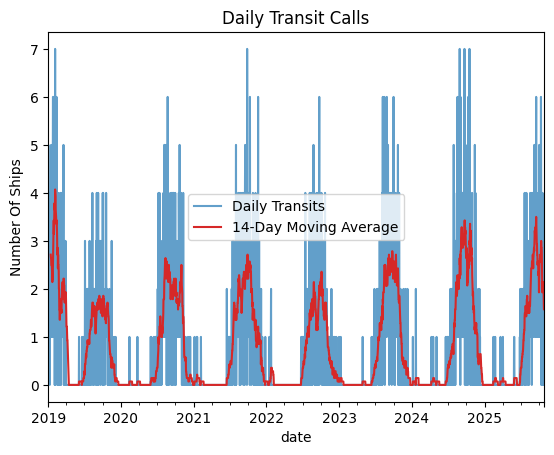

In [14]:
# Simple Plot of Transit Calls
# Note: 23 to 29 March 2021 Suez Canal obstruction Ever Given container ship
# Note: End of 2023 begin of Houthis attacks to commercial ships
ax = suez_canal.set_index(['date'])['n_total'].plot( # can change to capacity
    title='Daily Transit Calls',
    xlabel='',
    ylabel='Number Of Ships',
    alpha=0.7,
    label='Daily Transits'
)
suez_canal.set_index(['date'])['n_total'].rolling(14).mean().plot(
    ax=ax, color='#d62828', label='14-Day Moving Average')
ax.legend();

#### 2.5 Red Sea Chart

In [15]:
suez_canal = query_portwatch("Daily_Chokepoints_Data", where="portid='chokepoint1'")
cape_good_hope = query_portwatch("Daily_Chokepoints_Data", where="portid='chokepoint7'")

# Change Date field to date type
suez_canal['date'] = pd.to_datetime(suez_canal['date'])
cape_good_hope['date'] = pd.to_datetime(cape_good_hope['date'])

Querying PortWatch data Daily_Chokepoints_Data...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Chokepoints_Data/FeatureServer/0/query
{'where': "portid='chokepoint1'", 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 2491 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Chokepoints_Data/FeatureServer/0/query
{'where': "portid='chokepoint1'", 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 0}
Querying PortWatch data Daily_Chokepoints_Data...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Chokepoints_Data/FeatureServer/0/query
{'where': "portid='chokepoint7'", 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 2491 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Chokepoint

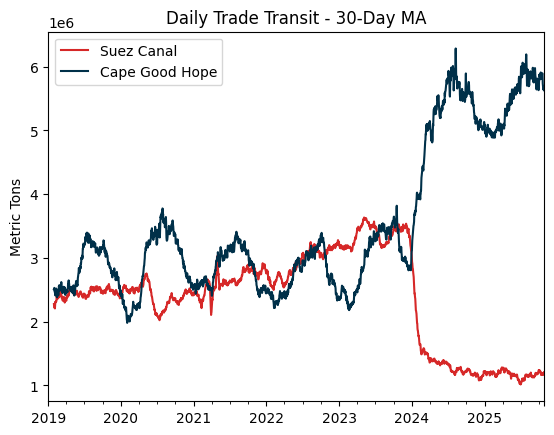

In [16]:
ax = suez_canal.set_index(['date'])['capacity'].rolling(30).mean().plot( # 30-day MA
    label='Suez Canal',
    color='#d62828'
)
cape_good_hope.set_index(['date'])['capacity'].rolling(30).mean().plot(
    ax=ax,
    label='Cape Good Hope',
    color='#003049'
)
ax.set_ylabel('Metric Tons')
ax.set_xlabel('')
ax.set_title('Daily Trade Transit - 30-Day MA')
ax.legend();

In [17]:
# Intercative Chart

# Calculate 30-day moving averages
suez_canal_rolling = suez_canal.set_index(['date'])['capacity'].rolling(14).mean()
cape_good_hope_rolling = cape_good_hope.set_index(['date'])['capacity'].rolling(14).mean()

# Create the plot
fig = go.Figure()

# Add the Suez Canal data (rolling average)
fig.add_trace(go.Scatter(
    x=suez_canal_rolling.index,
    y=suez_canal_rolling,
    mode='lines',
    name='Suez Canal',
    line=dict(color='#d62828')  # Red color
))

# Add the Cape of Good Hope data (rolling average)
fig.add_trace(go.Scatter(
    x=cape_good_hope_rolling.index,
    y=cape_good_hope_rolling,
    mode='lines',
    name='Cape Good Hope',
    line=dict(color='#003049')  # Dark blue color
))

# Update layout for labels and title
fig.update_layout(
    title='Daily Trade Transit - 30-Day MA',
    xaxis_title='Date',
    yaxis_title='Metric Tons',
    legend_title='Chokepoint',
    legend=dict(x=0.01, y=0.99),
    plot_bgcolor='#f0f0f0'# Adjust legend position
)

# Show the plot
fig.show()

### 3. Ports
In the following example we will query data from the Daily Port Activity and Trade Estimates <a href="https://portwatch.imf.org/datasets/75619cb86e5f4beeb7dab9629d861acf/about">dataset</a> and try to build country monitor

#### 3.1 All Ports covered in PortWatch

In [18]:
# Query the list with all Chokepoints metadata information
ports_metadata = query_portwatch("PortWatch_ports_database")
ports_metadata

Querying PortWatch data PortWatch_ports_database...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_ports_database/FeatureServer/0/query
{'where': '1=1', 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 1854 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/PortWatch_ports_database/FeatureServer/0/query
{'where': '1=1', 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 0}


,portid,portname,country,ISO3,continent,fullname,lat,lon,vessel_count_total,vessel_count_container,...,vessel_count_RoRo,vessel_count_tanker,industry_top1,industry_top2,industry_top3,share_country_maritime_import,share_country_maritime_export,LOCODE,pageid,countrynoaccents
0,port1325,Tsuruga,Japan,JPN,Asia & Pacific,"Tsuruga, Japan",35.667194,136.070611,492,51,...,183,47,Mineral Products,Wood & Wood Products,Vegetable Products,0.41,0.10,None,3b1f40eb8acd452ab6229331302891fe,Japan
1,port1198,Sibolga,Indonesia,IDN,Asia & Pacific,"Sibolga, Indonesia",1.734969,98.781715,79,27,...,9,35,Mineral Products,Prepared Foodstuffs & Beverages,Vegetable Products,0.08,0.01,None,4d00b008b4be4068bf8a19d7da6e8cf6,Indonesia
2,port339,Fangcheng,China,CHN,Asia & Pacific,"Fangcheng, China",21.614205,108.364339,1869,33,...,0,196,Mineral Products,Chemical & Allied Industries,Vegetable Products,1.97,0.38,None,266042b244cf452a89f4a2de14f3da2f,China
3,port1335,Ube,Japan,JPN,Asia & Pacific,"Ube, Japan",33.944875,131.213184,4686,11,...,0,2050,Mineral Products,Chemical & Allied Industries,"Plastics, Rubber, Leather",0.76,2.46,None,f3f6725ef00e4d3f8f9c93c45258667e,Japan
4,port153,Bluff Harbor,New Zealand,NZL,Asia & Pacific,"Bluff Harbor, New Zealand",-46.590130,168.360216,236,42,...,0,57,Wood & Wood Products,Metals,Prepared Foodstuffs & Beverages,7.81,2.79,None,894ab5e5a18e48b6922c023196f74c8f,New Zealand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1849,fso47,Equatorial Guinea - Offshore Oil Terminal 3,Equatorial Guinea,GNQ,Africa,"Equatorial Guinea - Offshore Oil Terminal 3, E...",1.409000,9.228000,0,0,...,0,0,None,None,None,0.00,1.15,None,28dc15477f984acc87a2f7be3817a4d2,Equatorial Guinea
1850,fso48,Guyana - Offshore Oil Terminal 1,Guyana,GUY,South America,"Guyana - Offshore Oil Terminal 1, Guyana",8.008000,-56.913000,37,0,...,1,36,None,None,None,3.64,37.91,None,1fbdae66657d40b2927dfb2f34886d7d,Guyana
1851,fso49,Guyana - Offshore Oil Terminal 2,Guyana,GUY,South America,"Guyana - Offshore Oil Terminal 2, Guyana",8.195000,-57.003000,14,0,...,0,14,None,None,None,0.45,15.57,None,5edd8a6ba28a47ad8af220cc46683c7a,Guyana
1852,fso50,Guyana - Offshore Oil Terminal 3,Guyana,GUY,South America,"Guyana - Offshore Oil Terminal 3, Guyana",8.010000,-56.992000,37,0,...,0,37,None,None,None,0.00,38.03,None,7ab8d534a7ab414ca72e9ceeeb9aa3b9,Guyana


#### 3.2. Map of all Ports

In [19]:
# Plot all chokepoints by converting lat and long into Points
ports_metadata_geo = gpd.GeoDataFrame(
    ports_metadata,
    geometry=gpd.points_from_xy(ports_metadata.lon, ports_metadata.lat),
    crs="EPSG:4326"
)
ports_metadata_geo.explore()

#### 3.3 Query Daily Port Activity Data and Trade Estimates for 1 Port

In [20]:
iso3 = "UKR"
country_ports = gpd.GeoDataFrame(
    ports_metadata[ports_metadata['ISO3']==iso3],
    geometry=gpd.points_from_xy(ports_metadata[ports_metadata['ISO3']==iso3].lon,
                                ports_metadata[ports_metadata['ISO3']==iso3].lat),
    crs="EPSG:4326"
)

print(country_ports.shape)

country_ports.explore()

(15, 23)


In [21]:
country_ports

,portid,portname,country,ISO3,continent,fullname,lat,lon,vessel_count_total,vessel_count_container,...,vessel_count_tanker,industry_top1,industry_top2,industry_top3,share_country_maritime_import,share_country_maritime_export,LOCODE,pageid,countrynoaccents,geometry
1083,port135,Berdyansk,Ukraine,UKR,Europe,"Berdyansk, Ukraine",46.752471,36.776569,136,2,...,3,Mineral Products,Vegetable Products,Metals,0.15,0.79,None,09047a11096d49a9abb3202cb6c9c56e,Ukraine,POINT (36.77657 46.75247)
1086,port489,Chornomorsk,Ukraine,UKR,Europe,"Chornomorsk, Ukraine",46.331599,30.656566,827,86,...,86,Vegetable Products,Mineral Products,Prepared Foodstuffs & Beverages,13.64,21.28,None,ab188f0a4a4c49a8970328d919530344,Ukraine,POINT (30.65657 46.3316)
1089,port559,Kerch,Ukraine,UKR,Europe,"Kerch, Ukraine",45.337536,36.463934,90,0,...,26,Mineral Products,Chemical & Allied Industries,Prepared Foodstuffs & Beverages,1.07,1.77,None,1cc88374479846bcb0e669e478e3e562,Ukraine,POINT (36.46393 45.33754)
1092,port707,Mariupol,Ukraine,UKR,Europe,"Mariupol, Ukraine",47.054354,37.505079,310,6,...,16,Mineral Products,Chemical & Allied Industries,Metals,0.22,2.32,UA MPW,a8d27289787d4b23a7ca7b9530d665ab,Ukraine,POINT (37.50508 47.05435)
1095,port782,Mykolaiv,Ukraine,UKR,Europe,"Mykolaiv, Ukraine",46.939475,32.015560,425,6,...,82,Mineral Products,Vegetable Products,Metals,3.24,9.63,UA NLV,82732d70884347bb858a2d1d65100f0b,Ukraine,POINT (32.01556 46.93947)
1098,port843,Odesa,Ukraine,UKR,Europe,"Odesa, Ukraine",46.501283,30.738071,802,206,...,65,Mineral Products,Vegetable Products,Chemical & Allied Industries,14.49,15.73,UA ODS,279b4ea79a064231bdec508f1437c13c,Ukraine,POINT (30.73807 46.50128)
1101,port1419,Pivdennyi,Ukraine,UKR,Europe,"Pivdennyi, Ukraine",46.633347,31.018057,694,70,...,126,Vegetable Products,Mineral Products,Prepared Foodstuffs & Beverages,31.01,36.53,None,007a49ba90c14de5ab525d82f091d549,Ukraine,POINT (31.01806 46.63335)
1377,port2001,Izmail,Ukraine,UKR,Europe,"Izmail, Ukraine",45.336104,28.809837,499,13,...,69,None,None,None,2.15,1.51,None,c0798af2e46a462a997daed4365facce,Ukraine,POINT (28.80984 45.3361)
1378,port2002,Reni,Ukraine,UKR,Europe,"Reni, Ukraine",45.424052,28.290122,459,17,...,93,None,None,None,1.41,1.67,None,bb2b3541b36142d3b9988dac872c6898,Ukraine,POINT (28.29012 45.42405)
1379,port2003,Olvia,Ukraine,UKR,Europe,"Olvia, Ukraine",46.810047,31.954398,493,7,...,53,None,None,None,30.94,8.01,None,0326e36f0a544523a85ac28bead67361,Ukraine,POINT (31.9544 46.81005)


In [22]:
# Query Port
# See for list of chokepoint-portid correspondance
one_port = query_portwatch("Daily_Trade_Data", where="portid='port489'") # Can try different chokepoints
one_port.tail()

Querying PortWatch data Daily_Trade_Data...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query
{'where': "portid='port489'", 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 2489 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query
{'where': "portid='port489'", 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 0}


,date,year,month,day,portid,portname,country,ISO3,portcalls_container,portcalls_dry_bulk,...,import_tanker,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export
2484,2025-10-20,2025,10,20,port489,Chornomorsk,Ukraine,UKR,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2485,2025-10-21,2025,10,21,port489,Chornomorsk,Ukraine,UKR,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2486,2025-10-22,2025,10,22,port489,Chornomorsk,Ukraine,UKR,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2487,2025-10-23,2025,10,23,port489,Chornomorsk,Ukraine,UKR,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2488,2025-10-24,2025,10,24,port489,Chornomorsk,Ukraine,UKR,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 3.4. Plot Daily Data

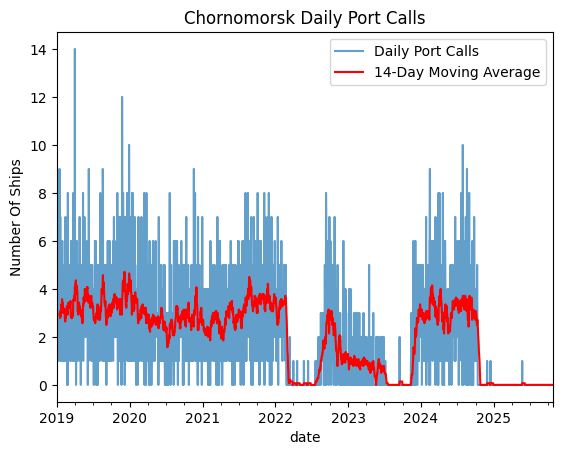

In [23]:
# Simple Plot of Portcalls
ax = one_port.set_index(['date'])['portcalls'].plot( # can change to import/export
    title=f'{one_port.iloc[0].portname} Daily Port Calls',
    xlabel='',
    ylabel='Number Of Ships',
    alpha=0.7,
    label='Daily Port Calls'
)
one_port.set_index(['date'])['portcalls'].rolling(14).mean().plot(
    ax=ax, color='red', label='14-Day Moving Average')
ax.legend();

#### By Ship Type

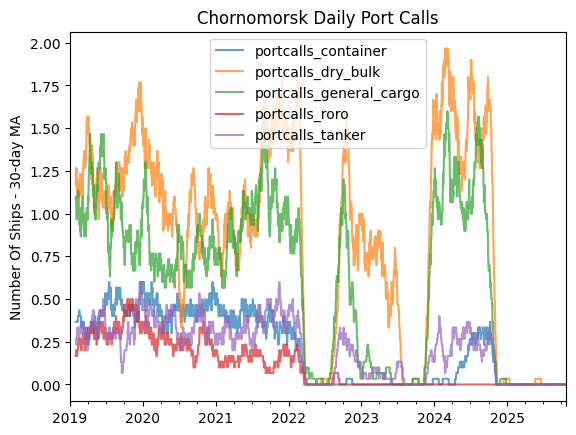

In [24]:
ax = one_port.set_index(['date'])[
    ['portcalls_container', 'portcalls_dry_bulk',
     'portcalls_general_cargo', 'portcalls_roro',
     'portcalls_tanker']
    ].rolling(30).mean().plot( # can change to import/export
    title=f'{one_port.iloc[0].portname} Daily Port Calls',
    xlabel='',
    ylabel='Number Of Ships - 30-day MA',
    alpha=0.7,
    legend=True
)
ax.legend();

### 4. Creating a Country monitoring dashboard

#### 4.1 Data Extraction

In [30]:
country = 'Ukraine'

In [31]:
df_trade = query_portwatch("Daily_Trade_Data", where=f"country='{country}'") #change country name to any country you want to query data for

Querying PortWatch data Daily_Trade_Data...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query
{'where': "country='Ukraine'", 'returnCountOnly': True, 'outFields': '*', 'f': 'json'}
Begin extraction of 37335 number of records...
Extracting batch of 5000 starting at record 0...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query
{'where': "country='Ukraine'", 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 0}
Extracting batch of 5000 starting at record 5000...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query
{'where': "country='Ukraine'", 'maxRecordCountFactor': 5, 'outFields': '*', 'f': 'json', 'resultOffset': 5000}
Extracting batch of 5000 starting at record 10000...
https://services9.arcgis.com/weJ1QsnbMYJlCHdG/arcgis/rest/services/Daily_Trade_Data/FeatureServer/0/query
{'where': "country='Ukrai

In [33]:
df_trade.head()

,date,year,month,day,portid,portname,country,ISO3,portcalls_container,portcalls_dry_bulk,...,import_tanker,import_cargo,import,export_container,export_dry_bulk,export_general_cargo,export_roro,export_tanker,export_cargo,export
0,2019-01-01,2019,1,1,port135,Berdyansk,Ukraine,UKR,0,0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
1,2019-01-01,2019,1,1,port489,Chornomorsk,Ukraine,UKR,0,0,...,0.0,0.000000,0.000000,0.000000,0.000000,6149.740684,0.0,0.0,6149.740684,6149.740684
2,2019-01-01,2019,1,1,port2077,Bilhorod-Dnistrovskyi,Ukraine,UKR,0,0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
3,2019-01-01,2019,1,1,port2234,Feodosiya,Ukraine,UKR,0,0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
4,2019-01-01,2019,1,1,port843,Odesa,Ukraine,UKR,2,1,...,0.0,1303.845559,1303.845559,5312.345034,61543.726629,0.000000,0.0,0.0,66856.071663,66856.071663


In [32]:
df_trade.to_csv(
    os.path.join(workshop_path, f"trade_data.csv"),
    index=False
)

In [26]:
# List of ports in the dataset
print("Extracted", df_trade.portname.nunique(), "ports")
df_trade.portname.unique()

Extracted 15 ports


array(['Berdyansk', 'Chornomorsk', 'Bilhorod-Dnistrovskyi', 'Feodosiya',
       'Odesa', 'Kerch', 'Reni', 'Mykolaiv', 'Kherson',
       'Port of Skadovsk', 'Mariupol', 'Pivdennyi', 'Izmail', 'Olvia',
       'Ust-Danube'], dtype=object)

In [27]:
df_trade.shape

(37335, 29)

#### 4.2 Data handling

In [28]:
# Calculating daily aggregates
def prepare_daily_data(df, ma=30):
    # Group by date, and portname and calculate the sum for total import and export
    daily_aggregates = df.groupby(['date'])[['import','export']].sum().rolling(ma).mean()
    return daily_aggregates

#### 4.3 Dashboard

In [29]:
# If needed on Colab, uncomment these:
# !pip install ipywidgets
# from google.colab import output as _colab_output; _colab_output.enable_custom_widget_manager()

import ipywidgets as widgets
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# ---- Widgets ----
portname_dropdown = widgets.Dropdown(
    options=[('Ukraine', '')] + [(portname, portname) for portname in df_trade['portname'].sort_values().unique()],
    description='Port Name:',
    value='',  # default: all ports
)

date_min = pd.to_datetime(df_trade['date'].min()).normalize()
date_max = pd.to_datetime(df_trade['date'].max()).normalize()
date_index = pd.date_range(start=date_min, end=date_max, freq='D')

date_slider = widgets.SelectionRangeSlider(
    options=[(date.strftime('%Y/%m/%d'), date) for date in date_index],
    index=(0, len(date_index) - 1),
    description='Date Range:',
    continuous_update=False,   # update when you release the handle
    layout=widgets.Layout(width='600px')
)

output = widgets.Output()

# ---- Update function ----
def render(_=None):
    with output:
        clear_output(wait=True)
        portname = portname_dropdown.value
        start_date, end_date = date_slider.value

        try:
            # Filter
            mask = df_trade['date'].between(start_date, end_date)
            filtered_df = df_trade.loc[mask]
            if portname != '':
                filtered_df = filtered_df.loc[filtered_df['portname'] == portname]

            # Prepare daily aggregates (expects columns: 'import', 'export'; index = date)
            daily_aggregates = prepare_daily_data(filtered_df)
            if daily_aggregates is None or daily_aggregates.empty:
                print("No data for the selected filters.")
                return

            daily_aggregates = daily_aggregates.copy()
            daily_aggregates.index = pd.to_datetime(daily_aggregates.index)
            daily_aggregates = daily_aggregates.sort_index()

            # Plot
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.plot(daily_aggregates.index, daily_aggregates['import'], label='Imports', marker='o', linewidth=1)
            ax.plot(daily_aggregates.index, daily_aggregates['export'], label='Exports', marker='o', linewidth=1)

            title_port = portname if portname != '' else 'All Ports'
            ax.set_title(f'Total Import and Export for {title_port}')
            ax.set_xlabel('Date')
            ax.set_ylabel('Metric Tons')
            ax.legend()
            ax.grid(True, alpha=0.3)
            fig.autofmt_xdate()
            plt.tight_layout()
            display(fig)
            plt.close(fig)

        except Exception as e:
            print(f"An error occurred: {e}")

# ---- Wire up auto-update ----
portname_dropdown.observe(render, names='value')
date_slider.observe(render, names='value')

# ---- Layout & initial draw ----
controls = widgets.VBox([portname_dropdown, date_slider])
display(controls, output)
render()  # initial render


Output()

In [ ]:
# Plot all ports by converting lat and long into Points
ukr_ports_metadata = ports_metadata[ports_metadata['country']=='Ukraine']
ports_metadata_geo = gpd.GeoDataFrame(
    ukr_ports_metadata,
    geometry=gpd.points_from_xy(ukr_ports_metadata.lon, ukr_ports_metadata.lat),
    crs="EPSG:4326"
)

# Display interactive map
ports_metadata_geo.explore(
    tooltip="portname",   # show portname when you hover
    popup=True,            # show all attributes when you click
    marker_kwds={"radius": 6, "fill": True, "fillOpacity": 0.8},
    style_kwds={"color": "blue"},
    name="Ukrainian Ports"
)